# 6. Data Visualization

This notebook introduces the data visualization capabilities available in the 3W Toolkit.

We will start with the core visualizations used for exploratory time-series analysis and then move to other features.

We'll use the 3W dataset to demonstrate these visualization techniques with real-world data from oil well operations.

## Learning goals

By the end of this notebook, you should be able to:

- visualize a single time series;
- compare multiple signals on the same axes;
- highlight missing values/events;
- inspect correlations between variables;
- inspect seasonal components through decomposition;
- analyse time series using `ThreeWChart` in an iterative manner.

## 📋 Table of Contents

1. [Data preparation](#data-preparation)
    1. [Loading the 3W Dataset](#load-the-3w-dataset)
2. [Plotting single time series](#plot-sigle-timeseries)
    1. [Customize](#single-timeseries-customization)
    2. [Highlighting missing values/events](#highlight-missings)
3. [Multiple Series - comparing multiple time series](#compare-multiple-timeseries)
4. [Correlation Heatmap](#correlation)
5. [Seasonal decomposition](#seasonal-decomposition)
6. [Putting the visualizations together](#visualization-together)
7. [ThreeWChart](#threewchart")
8. [Next Steps](#next-steps)
---

## 1. Data preparation <a id="data-preparation"></a>

We first import the libraries used throughout the notebook and load one instance from the 3W Dataset.

The examples use the current `ParquetDatasetConfig(...).build()` dataset initialization pattern.


**Packages**

In [1]:
import matplotlib.pyplot as plt

from ThreeWToolkit.data_visualization import DataVisualization
from ThreeWToolkit.dataset import ParquetDatasetConfig
from ThreeWToolkit.data_visualization import ThreeWChart

In [2]:
import numpy as np
import warnings

np.random.seed(42)
warnings.filterwarnings("ignore", category=UserWarning)

### Load the 3W dataset <a id="load-the-3w-dataset"></a>

In [3]:
ds = ParquetDatasetConfig(path="../../dataset").build()

print(f"Dataset length: {len(ds)}")

2026-09-28 11:59:26,138 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ..\..\dataset
2026-09-28 11:59:26,139 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-09-28 11:59:26,140 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


Dataset length: 2228


Let's select the signal of any event:

In [4]:
# Select one dataset instance and copy its signal DataFrame
sig = ds[123].signal.copy()

sig.head()[["P-TPT", "T-TPT", "P-ANULAR"]]

,P-TPT,T-TPT,P-ANULAR
timestamp,,,
2017-02-14 01:01:18,8447098.0,117.4970,11570750.0
2017-02-14 01:01:19,8447163.0,117.4969,11570750.0
2017-02-14 01:01:20,8447230.0,117.4968,11570750.0
2017-02-14 01:01:21,8447295.0,117.4969,11570750.0
2017-02-14 01:01:22,8447361.0,117.4971,11570750.0


## 2. Plotting a single time series <a id="plot-sigle-timeseries"></a>

`plot_series` is the simplest way to inspect one signal.

It accepts a pandas `Series` and returns a `(Figure, Axes)` tuple, which can be displayed with Matplotlib.


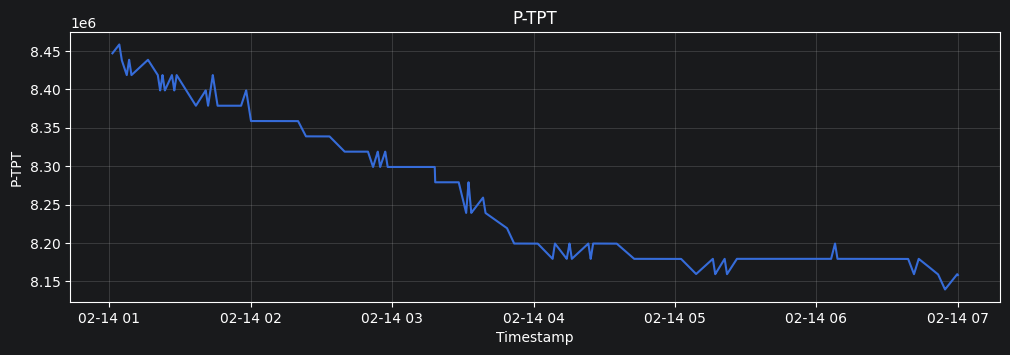

In [5]:
series = sig["P-TPT"]

fig, ax = plt.subplots(figsize=(12, 3.5))
DataVisualization.plot_series(
    series=series,
    title="P-TPT",
    xlabel="Timestamp",
    ylabel="P-TPT",
    ax = ax
)

fig.show()

### Customizing the plot <a id="single-timeseries-customization"></a>

Additional keyword arguments are forwarded to Matplotlib's `Axes.plot`, so common line properties can be customized directly.


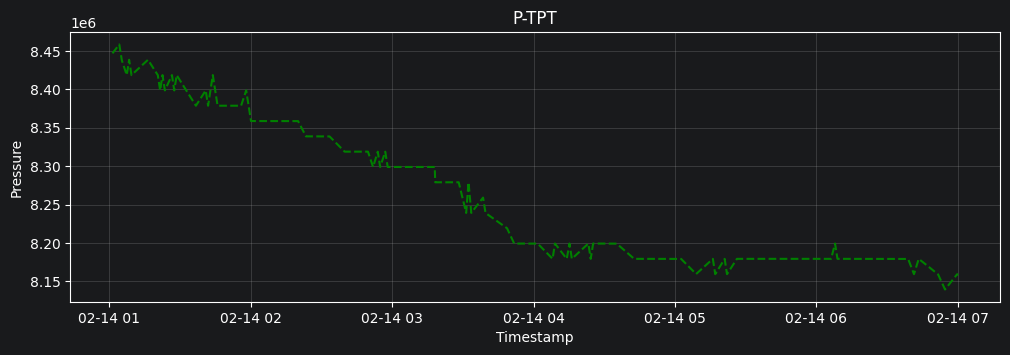

In [6]:
fig, ax = plt.subplots(figsize=(12, 3.5))
DataVisualization.plot_series(
    series=sig["P-TPT"],
    title="P-TPT",
    xlabel="Timestamp",
    ylabel="Pressure",
    color="green",
    linestyle="--",
    linewidth=1.5,
    ax=ax
)

fig.show()

### Highlighting missing values/events <a id="highlight-missings"></a>

When `overlay_events=True`, the visualization highlights positions where the input series contains `NaN` values.

This is useful for inspecting gaps, outages, or other situations represented by missing observations.


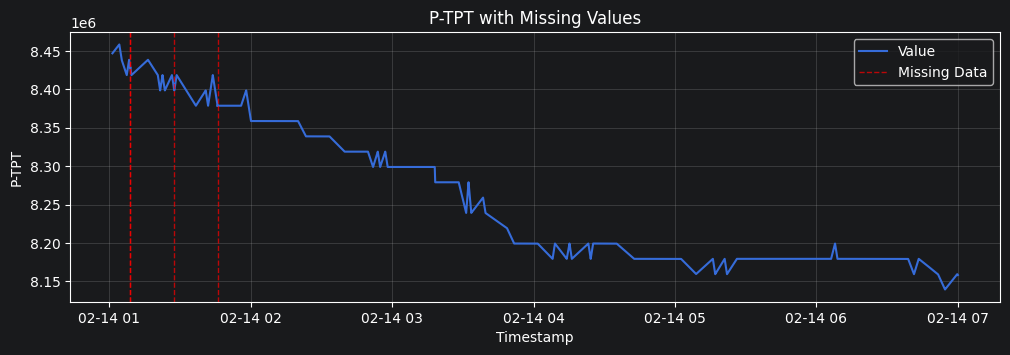

In [7]:
series_with_events = sig["P-TPT"].copy()

# Create a small, reproducible missing-data example
series_with_events.iloc[[456, 1567, 2678]] = np.nan

fig, ax = plt.subplots(figsize=(12, 3.5))
DataVisualization.plot_series(
    series=series_with_events,
    title="P-TPT with Missing Values",
    xlabel="Timestamp",
    ylabel="P-TPT",
    overlay_events=True,
    ax=ax
)

fig.show()


## 3. Comparing multiple time series <a id="compare-multiple-timeseries"></a>

`plot_multiple_series` draws several pandas Series on the same axes.

This is useful when the main question is how signals evolve relative to each other.


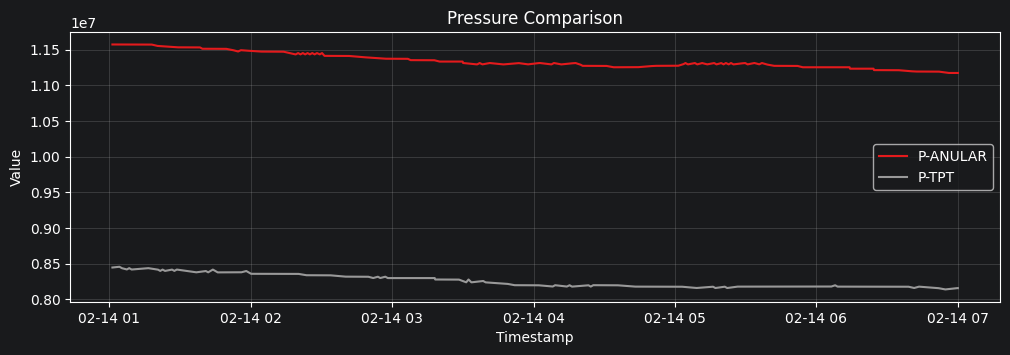

In [8]:
series_list = [
    sig["P-ANULAR"],
    sig["P-TPT"],
]

fig, axs = plt.subplots(1, 1, figsize=(12, 3.5))

DataVisualization.plot_multiple_series(
    series_list=series_list,
    labels=["P-ANULAR", "P-TPT"],
    title="Pressure Comparison",
    xlabel="Timestamp",
    ylabel="Value",
    ax=axs
)

plt.show()

### Using subplots

The visualization methods accept an optional Matplotlib `Axes`. This makes it possible to compose several toolkit visualizations into one figure.


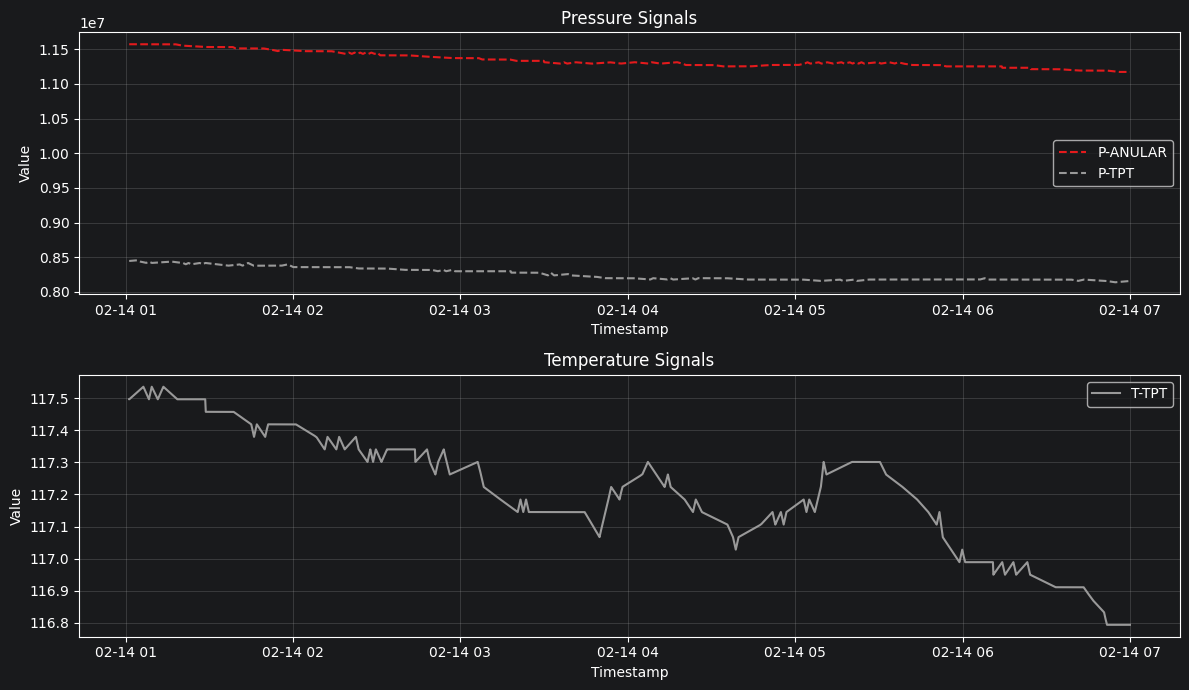

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(12, 7))

DataVisualization.plot_multiple_series(
    series_list=[sig["P-ANULAR"], sig["P-TPT"]],
    labels=["P-ANULAR", "P-TPT"],
    title="Pressure Signals",
    xlabel="Timestamp",
    ylabel="Value",
    ax=axs[0],
    linestyle="--",
)

DataVisualization.plot_multiple_series(
    series_list=[sig["T-JUS-CKP"], sig["T-TPT"]],
    labels=["T-JUS-CKP", "T-TPT"],
    title="Temperature Signals",
    xlabel="Timestamp",
    ylabel="Value",
    ax=axs[1],
)

plt.tight_layout()
plt.show()


## 4. Exploring feature correlations <a id="correlation"></a>

`correlation_heatmap` computes and displays the correlation structure of the variables in a DataFrame.

A useful workflow is to first select a small group of physically or operationally related signals.


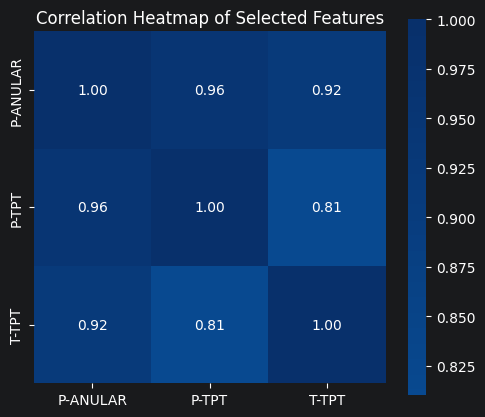

In [10]:
features = [
    "P-ANULAR",
    "P-TPT",
    "T-TPT",
]

subset = sig[features]

fig, _ = DataVisualization.correlation_heatmap(
    df_of_series=subset,
    title="Correlation Heatmap of Selected Features",
    cmap="Blues",
    figsize=(5, 5)
)

fig.show()


### Customizing the heatmap

Keyword arguments are passed to the underlying heatmap implementation, allowing annotations and different color maps.


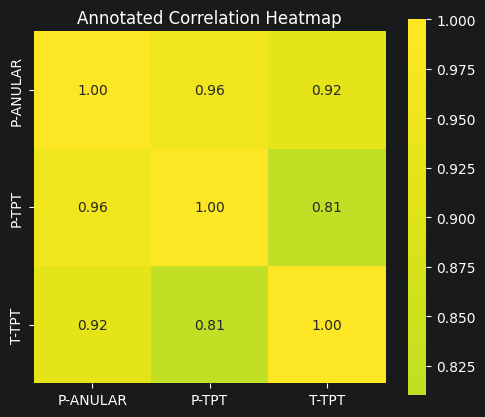

In [11]:
fig, _ = DataVisualization.correlation_heatmap(
    df_of_series=subset,
    title="Annotated Correlation Heatmap",
    annot=True,
    cmap="viridis",
    fmt=".2f",
    figsize=(5, 5)
)

fig.show()


## 5. Seasonal decomposition <a id="seasonal-decomposition"></a>

`seasonal_decompose` separates a time series into its main components according to the selected model.

The `period` should reflect the expected seasonal period of the signal.


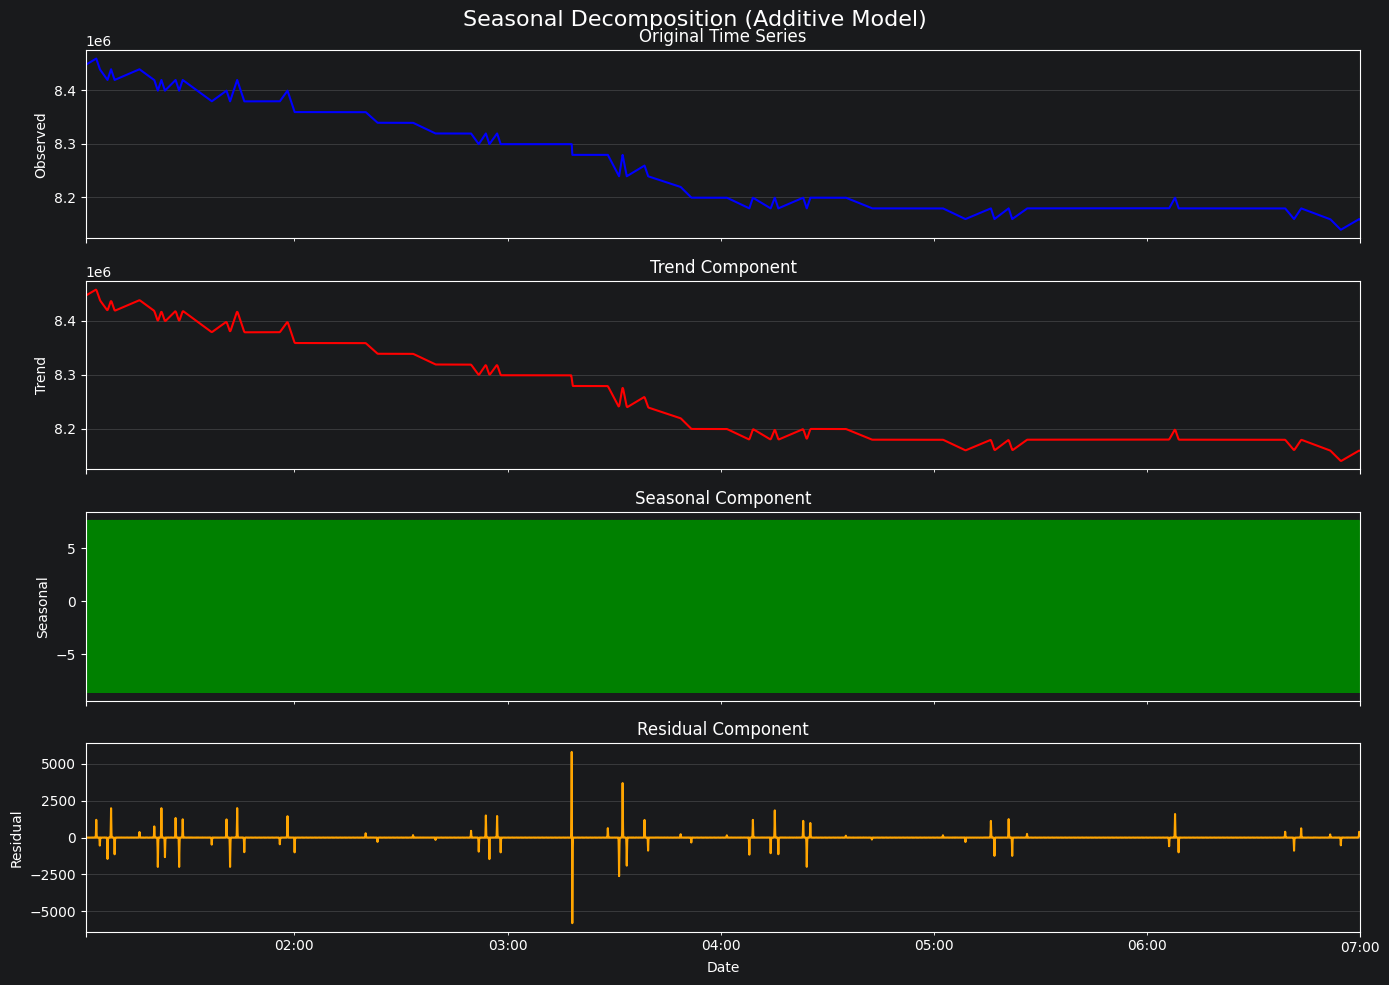

In [12]:
fig, _ = DataVisualization.seasonal_decompose(
    series=sig["P-TPT"],
    model="additive",
    period=24,
)

fig.show()


> **Note:** The appropriate `period` depends on the sampling frequency and the phenomenon being analyzed. The value above is an example for demonstration and should be adapted to the signal being studied.


## 6. Putting the visualizations together <a id="visualization-together"></a>

A typical exploratory workflow can combine several views of the same signals:

1. inspect the raw time series;
2. compare related variables;
3. identify missing values/events;
4. inspect correlations;
5. move to frequency or time-frequency analysis when appropriate.

The toolkit methods can be combined with regular Matplotlib figures because they accept an optional `Axes`.


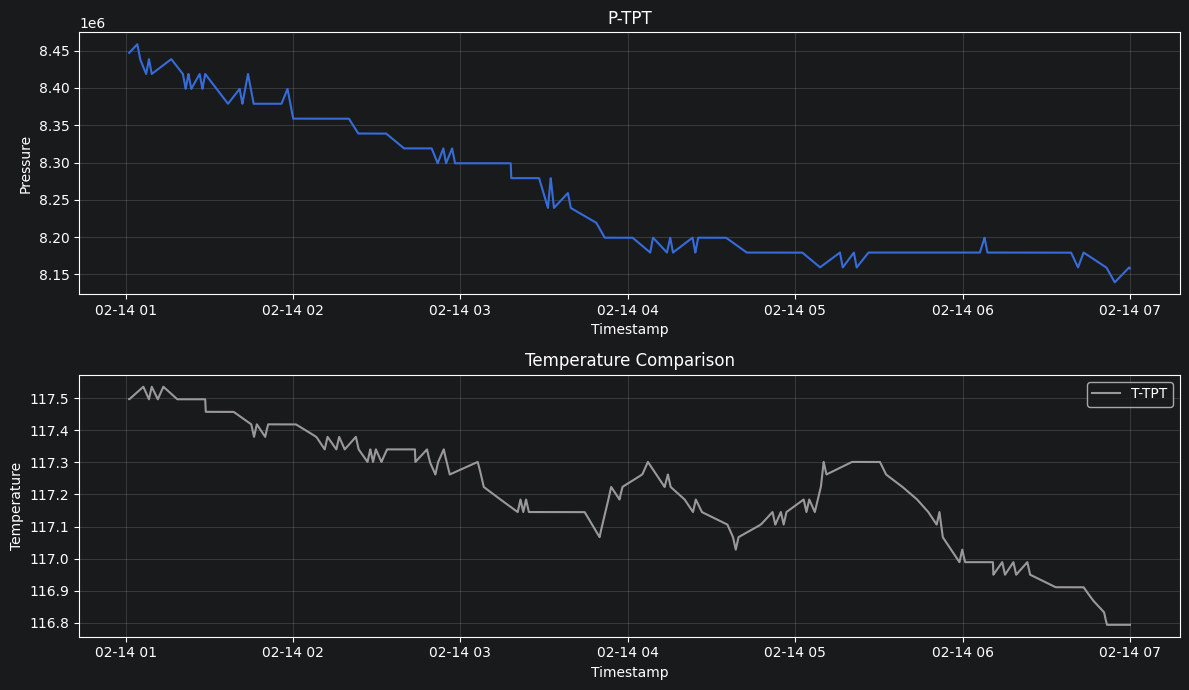

In [13]:
fig, axs = plt.subplots(2, 1, figsize=(12, 7))

DataVisualization.plot_series(
    series=sig["P-TPT"],
    title="P-TPT",
    xlabel="Timestamp",
    ylabel="Pressure",
    ax=axs[0],
)

DataVisualization.plot_multiple_series(
    series_list=[sig["T-JUS-CKP"], sig["T-TPT"]],
    labels=["T-JUS-CKP", "T-TPT"],
    title="Temperature Comparison",
    xlabel="Timestamp",
    ylabel="Temperature",
    ax=axs[1],
)

plt.tight_layout()
plt.show()


## 7. ThreeWChart <a id="threewchart"></a>

**ThreeWChart** is included here as a community-contributed visualization example.


To visualize the 3W Dataset, the data is loaded from the Parquet files present in the `dataset` directory. The data is then processed to create a Plotly figure that can be displayed using the `plot` method.

In [14]:
chart = ThreeWChart(
    file_path="../../dataset/1/WELL-00001_20140124083303.parquet",
    title="ThreeWChart Usage Example",
)
fig, _ = chart.plot()
fig.show()

### Viewing Variables via the Dropdown Menu

In order to make it easier to view different variables, you can use the dropdown menu to select the event to display. The dropdown includes only the events present in the Parquet file.

Set the `use_dropdown` parameter to `True` to enable this feature.

In [15]:
chart = ThreeWChart(
    file_path="../../dataset/4/WELL-00001_20170316170000.parquet",
    title="ThreeWChart Usage Example",
    use_dropdown=True,
    dropdown_position=(0.5, 1.4),
)
fig, _ = chart.plot()
fig.show()

## Next steps <a id="next-steps"></a>

🎉 **Nice!** Now you can use the **3W Toolkit** data visualization tools!

Continue to the next workshop notebook to explore feature extraction and how the visualized signals can be transformed into useful representations for downstream analysis.

### What's Next?

1. **Explore Preprocessing and FeatureExtraction**: Learn about data preparation and discover advanced features in [Notebook 7: Preprocessing](7_feature_extraction.ipynb)
2. **Model Training**: Discover how to train machine learning models in [Notebook 8: Model Training](8_model_training.ipynb)
---